# 🚦 US Accidents — End-to-End Machine Learning Pipeline
### Predicting Accident Severity (1–4) | 2016–2023

---

**Pipeline Stages**

| # | Stage | Description |
|---|-------|-------------|
| 1 | Data Ingestion | Load dataset, inspect shape & dtypes |
| 2 | Data Cleaning | Handle nulls, duplicates, outliers |
| 3 | Preprocessing & Feature Engineering | Encode, scale, temporal features |
| 4 | Data Validation | Schema checks, distribution tests |
| 5 | EDA | Univariate, bivariate, correlation, geo |
| 6 | Modeling | LR · RF · XGBoost · LightGBM · MLP |
| 7 | Evaluation & Comparison | Accuracy, F1, ROC-AUC, confusion matrices |
| 8 | Feature Importance | SHAP + built-in importances |
| 9 | Summary | Winner table + recommendations |

> **Dataset:** [US Accidents (2016–2023)](https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents) — 7.7M+ records, 46 features.  
> Download `US_Accidents_March23.csv` from Kaggle and place it in the same directory as this notebook.


## 0 · Imports & Configuration

In [1]:

import warnings, os, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display, HTML

# ── Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.inspection import permutation_importance

# ── Gradient Boosting
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ── Imbalanced
from imblearn.over_sampling import SMOTE

# ── Plot style
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
PALETTE = ["#2563EB", "#16A34A", "#DC2626", "#D97706", "#7C3AED"]
SEVERITY_COLORS = {1:"#22C55E", 2:"#EAB308", 3:"#F97316", 4:"#EF4444"}

print(" All libraries imported successfully")


✅ All libraries imported successfully


## 1 · Data Ingestion

In [8]:
import pandas as pd
import time
import os

# First, check what files are actually there
dataset_dir = "/kaggle/input/datasets/sobhanmoosavi/us-accidents/US_Accidents_March23.csv"
print("📁 Contents:", os.listdir(dataset_dir))

# Adjust this to the actual CSV filename (example: 'US_accidents.csv')
CSV_PATH = os.path.join(dataset_dir, "US_accidents.csv")

print(f"📂 Loading: {CSV_PATH}")
t0 = time.time()
df_raw = pd.read_csv(CSV_PATH, low_memory=False)
print(f"   Loaded in {time.time()-t0:.1f}s  |  Shape: {df_raw.shape}")

# ── Quick snapshot ─────────────────────────────────────────────────────────────
print("\n── Column overview ──")
info_df = pd.DataFrame({
    "dtype": df_raw.dtypes,
    "nulls": df_raw.isnull().sum(),
    "null_%": (df_raw.isnull().mean()*100).round(2),
    "unique": df_raw.nunique()
})
display(info_df.sort_values("null_%", ascending=False).head(30))

📁 Contents: ['US_Accidents_March23.csv']
📂 Loading: /kaggle/input/datasets/sobhanmoosavi/us-accidents/US_Accidents_March23.csv
   Loaded in 123.1s  |  Shape: (7728394, 46)

── Column overview ──


,dtype,nulls,null_%,unique
End_Lng,float64,3402762,44.03,1605789
End_Lat,float64,3402762,44.03,1568172
Precipitation(in),float64,2203586,28.51,299
Wind_Chill(F),float64,1999019,25.87,1001
Wind_Speed(mph),float64,571233,7.39,184
Visibility(mi),float64,177098,2.29,92
Wind_Direction,object,175206,2.27,24
Humidity(%),float64,174144,2.25,100
Weather_Condition,object,173459,2.24,144
Temperature(F),float64,163853,2.12,860


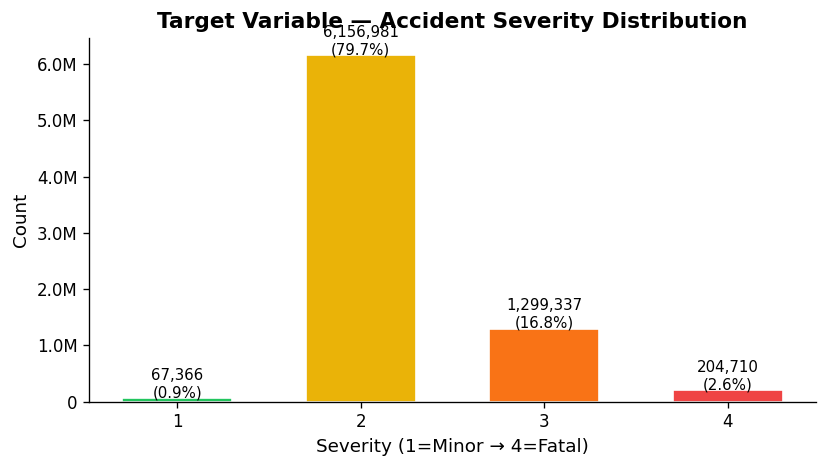

Severity
1      67366
2    6156981
3    1299337
4     204710
Name: count, dtype: int64


In [9]:

# ── Target distribution ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
counts = df_raw["Severity"].value_counts().sort_index()
bars = ax.bar(counts.index.astype(str), counts.values,
              color=[SEVERITY_COLORS[i] for i in counts.index], edgecolor="white", width=0.6)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+15000,
            f"{val:,}\n({val/len(df_raw)*100:.1f}%)", ha="center", fontsize=9)
ax.set_title("Target Variable — Accident Severity Distribution", fontweight="bold")
ax.set_xlabel("Severity (1=Minor → 4=Fatal)")
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M" if x>=1e6 else f"{int(x):,}"))
plt.tight_layout()
plt.savefig("01_target_distribution.png", bbox_inches="tight")
plt.show()
print(counts)


## 2 · Data Cleaning

In [10]:

df = df_raw.copy()

# ── 2.1 Drop columns with >40% missing ─────────────────────────────────────────
high_null_cols = df.columns[df.isnull().mean() > 0.40].tolist()
print(f"Dropping {len(high_null_cols)} high-null columns: {high_null_cols}")
df.drop(columns=high_null_cols, inplace=True)

# ── 2.2 Remove exact duplicates ────────────────────────────────────────────────
n_before = len(df)
df.drop_duplicates(subset=["ID"], inplace=True)
print(f"Removed {n_before - len(df):,} duplicate IDs")

# ── 2.3 Drop irrelevant / leakage columns ──────────────────────────────────────
DROP_COLS = ["ID", "Description", "Street", "Zipcode",
             "Country", "Timezone", "Airport_Code",
             "Weather_Timestamp", "Wind_Direction",
             "Civil_Twilight", "Nautical_Twilight", "Astronomical_Twilight"]
DROP_COLS = [c for c in DROP_COLS if c in df.columns]
df.drop(columns=DROP_COLS, inplace=True)
print(f"Dropped {len(DROP_COLS)} irrelevant/leakage columns")

# ── 2.4 Parse datetime ─────────────────────────────────────────────────────────
for col in ["Start_Time", "End_Time"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# ── 2.5 Fill numeric nulls with median ─────────────────────────────────────────
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "Severity"]
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# ── 2.6 Fill categorical nulls ─────────────────────────────────────────────────
cat_cols = df.select_dtypes(include=["object", "bool"]).columns.tolist()
for col in cat_cols:
    df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else "Unknown", inplace=True)

# ── 2.7 Outlier capping (IQR × 3) for numeric features ─────────────────────────
for col in ["Temperature(F)", "Wind_Speed(mph)", "Precipitation(in)", "Visibility(mi)"]:
    if col in df.columns:
        q1, q3 = df[col].quantile(0.01), df[col].quantile(0.99)
        df[col] = df[col].clip(q1, q3)

print(f"\n  Clean shape: {df.shape}")
print(f"   Remaining nulls: {df.isnull().sum().sum():,}")


Dropping 2 high-null columns: ['End_Lat', 'End_Lng']
Removed 0 duplicate IDs
Dropped 12 irrelevant/leakage columns

✅ Clean shape: (7728394, 32)
   Remaining nulls: 1,486,332


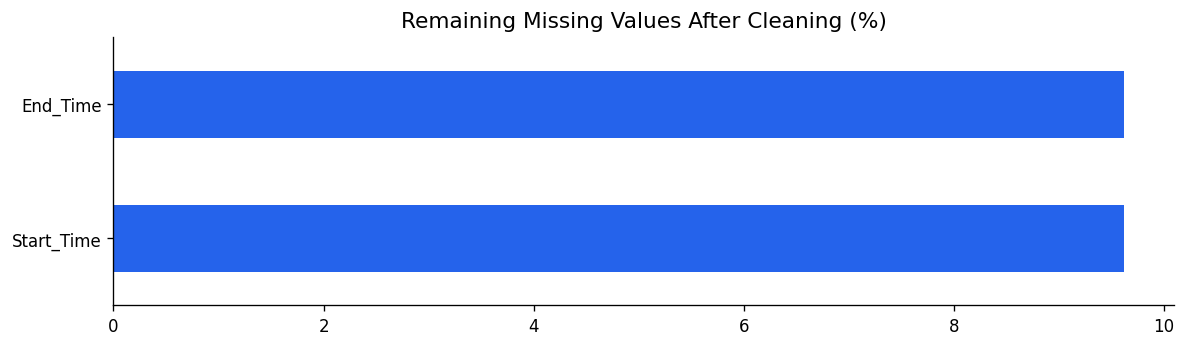

In [11]:

# ── Null heatmap after cleaning ─────────────────────────────────────────────────
null_pct = df.isnull().mean() * 100
null_pct = null_pct[null_pct > 0]
if len(null_pct) > 0:
    fig, ax = plt.subplots(figsize=(10, 3))
    null_pct.sort_values().plot(kind="barh", ax=ax, color="#2563EB")
    ax.set_title("Remaining Missing Values After Cleaning (%)")
    plt.tight_layout(); plt.show()
else:
    print(" No missing values remaining.")


## 3 · Feature Engineering & Preprocessing

In [12]:

# ── 3.1 Temporal features ──────────────────────────────────────────────────────
if "Start_Time" in df.columns:
    df["Hour"]        = df["Start_Time"].dt.hour
    df["DayOfWeek"]   = df["Start_Time"].dt.dayofweek
    df["Month"]       = df["Start_Time"].dt.month
    df["Year"]        = df["Start_Time"].dt.year
    df["IsWeekend"]   = (df["DayOfWeek"] >= 5).astype(int)
    df["IsRushHour"]  = df["Hour"].isin([7,8,9,16,17,18]).astype(int)
    df["IsDaylight"]  = df["Hour"].between(6, 20).astype(int)

# ── 3.2 Duration feature ───────────────────────────────────────────────────────
if "Start_Time" in df.columns and "End_Time" in df.columns:
    df["Duration_min"] = (df["End_Time"] - df["Start_Time"]).dt.total_seconds() / 60
    df["Duration_min"] = df["Duration_min"].clip(0, 1440)  # cap at 24 hours

# ── Drop raw datetime ──────────────────────────────────────────────────────────
df.drop(columns=["Start_Time","End_Time"], errors="ignore", inplace=True)

# ── 3.3 Encode booleans ────────────────────────────────────────────────────────
bool_cols = df.select_dtypes(include=["bool"]).columns.tolist()
for col in bool_cols:
    df[col] = df[col].astype(int)

# ── 3.4 Label-encode low-cardinality categoricals, target-encode high ──────────
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    if df[col].nunique() <= 50:
        df[col] = le.fit_transform(df[col].astype(str))
    else:
        # Target encoding for high-cardinality (e.g. City, County)
        enc = df.groupby(col)["Severity"].mean()
        df[col] = df[col].map(enc).fillna(df["Severity"].mean())

print(f"Feature matrix shape: {df.shape}")
print(f"Features: {[c for c in df.columns if c != 'Severity'][:10]} ...")


Feature matrix shape: (7728394, 38)
Features: ['Source', 'Start_Lat', 'Start_Lng', 'Distance(mi)', 'City', 'County', 'State', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)'] ...


In [14]:
# ── 3.5 Handle missing values BEFORE scaling ─────────────────────────────────
# Choose a strategy: 'median' for numeric, 'most_frequent' for categorical
# Since you're scaling, we'll impute numeric columns first.

# Separate numeric and non-numeric columns (if any)
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

# Impute numeric columns with median (robust to outliers)
from sklearn.impute import SimpleImputer
num_imputer = SimpleImputer(strategy='median')
X_numeric_imputed = num_imputer.fit_transform(X[numeric_cols])


X_processed = pd.DataFrame(X_numeric_imputed, columns=numeric_cols)


X = X_processed

# ── 3.6 Sample for speed (optional) ─────────────────────────────────────────
SAMPLE_SIZE = 300_000
if len(X) > SAMPLE_SIZE:
    # Sample indices together with y
    sample_idx = np.random.RandomState(42).choice(len(X), SAMPLE_SIZE, replace=False)
    X = X[sample_idx]
    y = y.iloc[sample_idx].reset_index(drop=True) if isinstance(y, pd.Series) else y[sample_idx]
    print(f"ℹ️  Sampled {SAMPLE_SIZE:,} rows for pipeline speed.")

# ── 3.7 Train / Validation / Test split ──────────────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)
print(f"Train: {X_train.shape[0]:,} | Val: {X_val.shape[0]:,} | Test: {X_test.shape[0]:,}")

# ── 3.8 Feature scaling ──────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# ── 3.9 SMOTE (now no NaNs) ──────────────────────────────────────────────────
print("\nApplying SMOTE …")
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)
print(f"After SMOTE — Train size: {X_train_sm.shape[0]:,}")
print(pd.Series(y_train_sm).value_counts().sort_index().rename({0:"Sev-1",1:"Sev-2",2:"Sev-3",3:"Sev-4"}))

Train: 210,000 | Val: 45,000 | Test: 45,000

Applying SMOTE …
After SMOTE — Train size: 668,588
Severity
Sev-1    167147
Sev-2    167147
Sev-3    167147
Sev-4    167147
Name: count, dtype: int64


## 4 · Data Validation

In [15]:

print("=" * 60)
print("DATA VALIDATION REPORT")
print("=" * 60)

checks = {}

# ── 4.1 Schema check ──────────────────────────────────────────────────────────
expected_types = {"Hour": np.integer, "Month": np.integer,
                  "Temperature(F)": np.floating, "Severity": np.integer}
schema_ok = True
for col, dtype in expected_types.items():
    if col in df.columns:
        match = np.issubdtype(df[col].dtype, dtype)
        if not match:
            print(f"  ❌ Schema: {col} expected {dtype}, got {df[col].dtype}")
            schema_ok = False
checks["Schema"] = "✅ PASS" if schema_ok else "❌ FAIL"

# ── 4.2 Range checks ──────────────────────────────────────────────────────────
range_ok = True
range_tests = {
    "Severity": (1, 4),
    "Hour": (0, 23),
    "Month": (1, 12),
    "DayOfWeek": (0, 6)
}
for col, (lo, hi) in range_tests.items():
    if col in df.columns:
        out_of_range = ((df[col] < lo) | (df[col] > hi)).sum()
        if out_of_range > 0:
            print(f"  ❌ Range: {col} has {out_of_range} out-of-range values")
            range_ok = False
checks["Range"] = "✅ PASS" if range_ok else "❌ FAIL"

# ── 4.3 Null check ────────────────────────────────────────────────────────────
total_nulls = df.isnull().sum().sum()
checks["No Nulls"] = "✅ PASS" if total_nulls == 0 else f"⚠️  {total_nulls:,} nulls"

# ── 4.4 Class leakage check ───────────────────────────────────────────────────
test_ids_in_train = set(X_test.index) & set(X_train.index)
checks["No Leakage"] = "✅ PASS" if len(test_ids_in_train) == 0 else "❌ FAIL"

# ── 4.5 Duplicate check ───────────────────────────────────────────────────────
dup_count = X.duplicated().sum()
checks["No Duplicates"] = "✅ PASS" if dup_count == 0 else f"⚠️  {dup_count:,} dupes"

# ── 4.6 SMOTE integrity ───────────────────────────────────────────────────────
smote_classes = len(np.unique(y_train_sm))
checks["SMOTE Balanced"] = "✅ PASS" if smote_classes == 4 else "❌ FAIL"

print()
for check, result in checks.items():
    print(f"  {result}  {check}")
print("\n" + "=" * 60)
all_pass = all("PASS" in v for v in checks.values())
print(f"Overall: {'✅ ALL CHECKS PASSED' if all_pass else '⚠️  Some checks need attention'}")


DATA VALIDATION REPORT
  ❌ Schema: Hour expected <class 'numpy.integer'>, got float64
  ❌ Schema: Month expected <class 'numpy.integer'>, got float64

  ❌ FAIL  Schema
  ✅ PASS  Range
  ⚠️  143,955 nulls  No Nulls
  ✅ PASS  No Leakage
  ⚠️  333 dupes  No Duplicates
  ✅ PASS  SMOTE Balanced

Overall: ⚠️  Some checks need attention


## 5 · Exploratory Data Analysis (EDA)

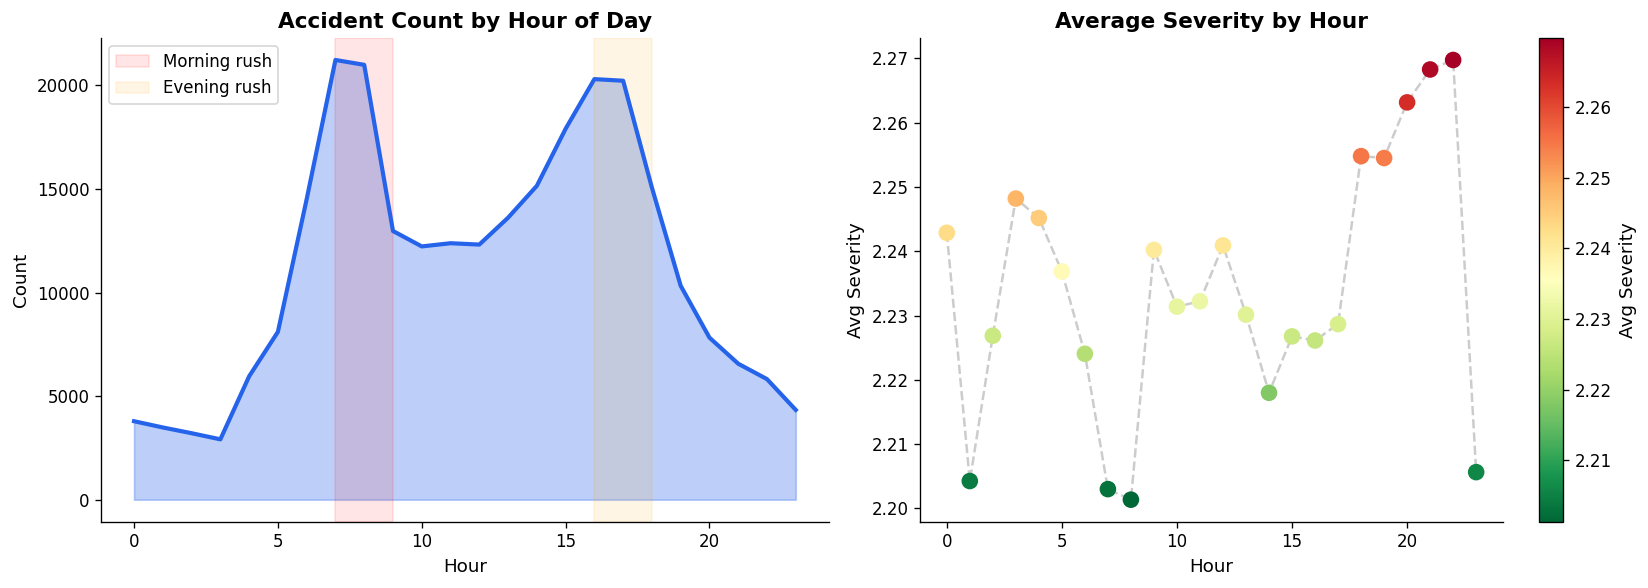

In [16]:

# ── 5.1 Severity by Hour of Day ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accidents per hour
hour_counts = df.groupby("Hour").size()
axes[0].fill_between(hour_counts.index, hour_counts.values, alpha=0.3, color="#2563EB")
axes[0].plot(hour_counts.index, hour_counts.values, color="#2563EB", linewidth=2.5)
axes[0].set_title("Accident Count by Hour of Day", fontweight="bold")
axes[0].set_xlabel("Hour"); axes[0].set_ylabel("Count")
axes[0].axvspan(7, 9, alpha=0.1, color="red", label="Morning rush")
axes[0].axvspan(16, 18, alpha=0.1, color="orange", label="Evening rush")
axes[0].legend()

# Avg severity per hour
avg_sev = df.groupby("Hour")["Severity"].mean()
sc = axes[1].scatter(avg_sev.index, avg_sev.values,
                     c=avg_sev.values, cmap="RdYlGn_r", s=80, zorder=3)
axes[1].plot(avg_sev.index, avg_sev.values, "--", alpha=0.4, color="gray")
plt.colorbar(sc, ax=axes[1], label="Avg Severity")
axes[1].set_title("Average Severity by Hour", fontweight="bold")
axes[1].set_xlabel("Hour"); axes[1].set_ylabel("Avg Severity")

plt.tight_layout()
plt.savefig("05a_hour_analysis.png", bbox_inches="tight")
plt.show()


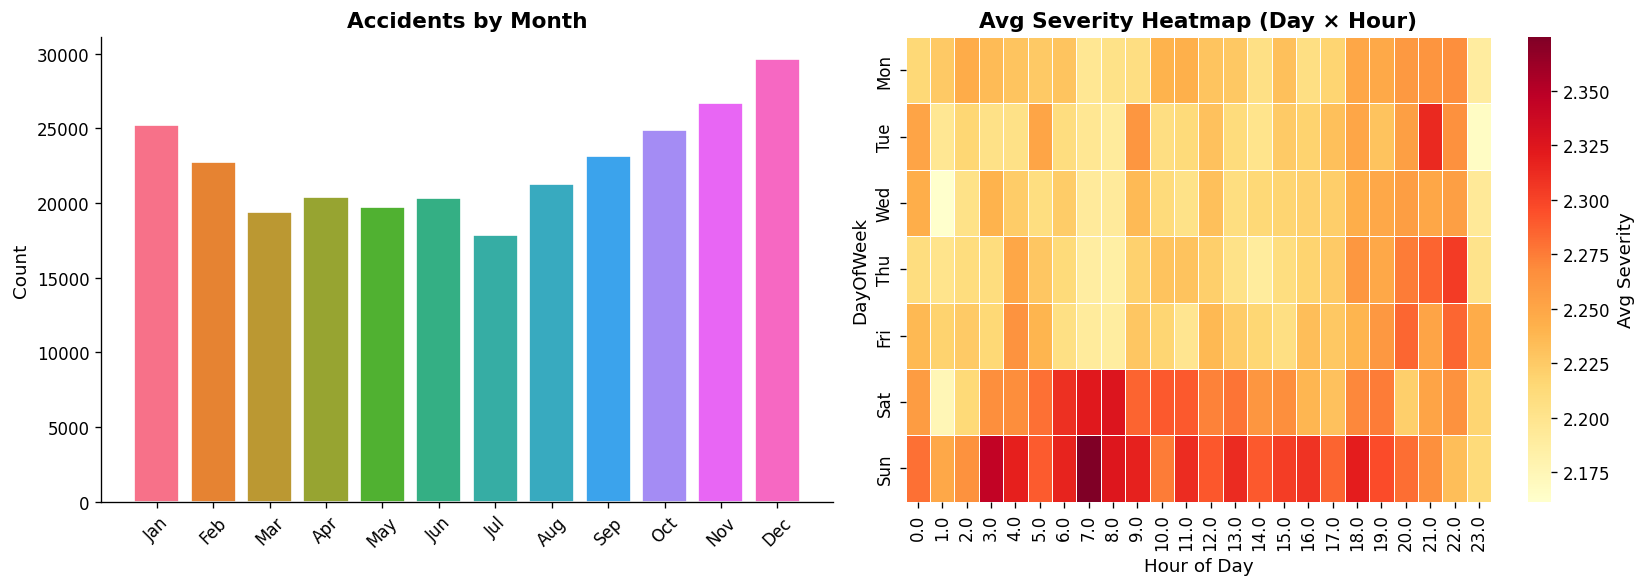

In [17]:

# ── 5.2 Monthly & Seasonal Trends ─────────────────────────────────────────────
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

monthly = df.groupby("Month").size()
axes[0].bar(range(1,13), monthly.values, color=sns.color_palette("husl", 12), edgecolor="white")
axes[0].set_xticks(range(1,13)); axes[0].set_xticklabels(month_names, rotation=45)
axes[0].set_title("Accidents by Month", fontweight="bold")
axes[0].set_ylabel("Count")

# Severity heatmap by Day x Hour
pivot = df.groupby(["DayOfWeek","Hour"])["Severity"].mean().unstack()
day_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
sns.heatmap(pivot, ax=axes[1], cmap="YlOrRd", linewidths=0.3,
            yticklabels=day_labels, cbar_kws={"label":"Avg Severity"})
axes[1].set_title("Avg Severity Heatmap (Day × Hour)", fontweight="bold")
axes[1].set_xlabel("Hour of Day")

plt.tight_layout()
plt.savefig("05b_temporal_patterns.png", bbox_inches="tight")
plt.show()


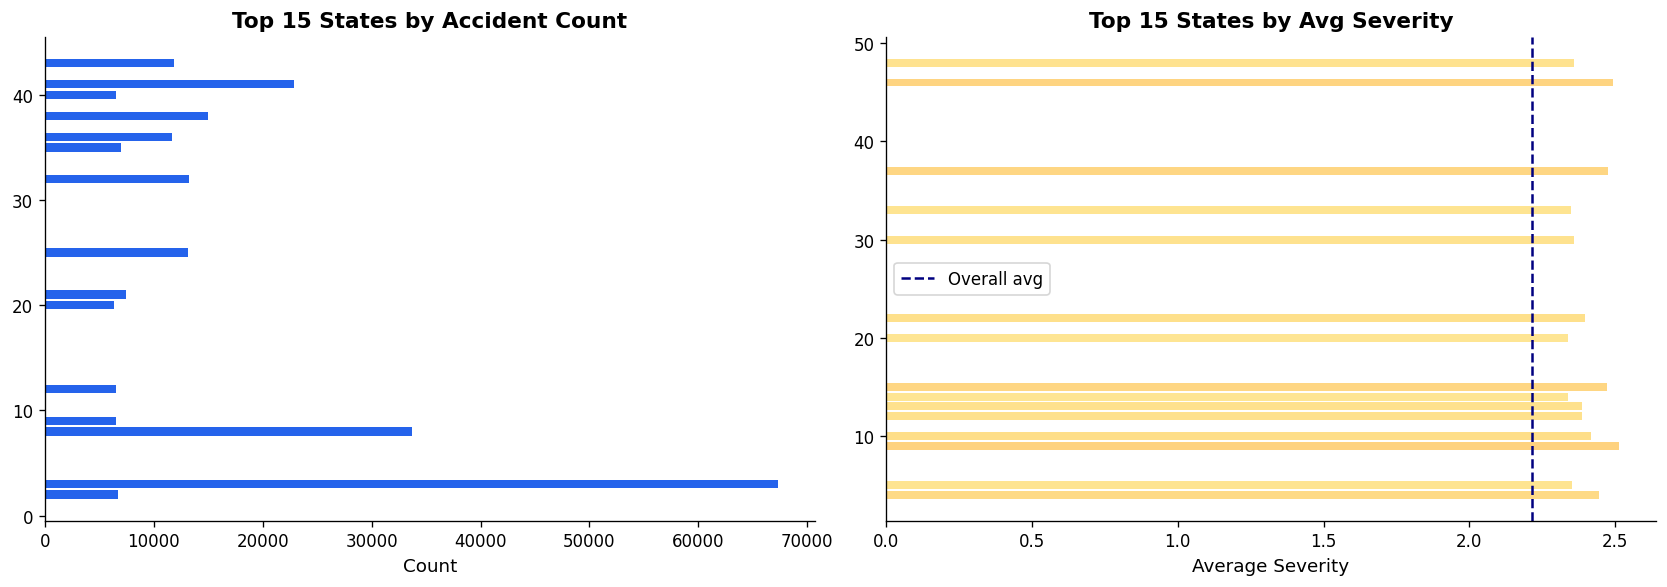

In [18]:

# ── 5.3 Top States & Cities ────────────────────────────────────────────────────
if "State" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    top_states = df["State"].value_counts().head(15)
    axes[0].barh(top_states.index[::-1], top_states.values[::-1], color="#2563EB")
    axes[0].set_title("Top 15 States by Accident Count", fontweight="bold")
    axes[0].set_xlabel("Count")

    # Avg severity by state
    state_sev = df.groupby("State")["Severity"].mean().sort_values(ascending=False).head(15)
    axes[1].barh(state_sev.index[::-1], state_sev.values[::-1],
                 color=[plt.cm.RdYlGn_r(v/4) for v in state_sev.values[::-1]])
    axes[1].set_title("Top 15 States by Avg Severity", fontweight="bold")
    axes[1].set_xlabel("Average Severity")
    axes[1].axvline(df["Severity"].mean(), color="navy", linestyle="--", label="Overall avg")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("05c_state_analysis.png", bbox_inches="tight")
    plt.show()


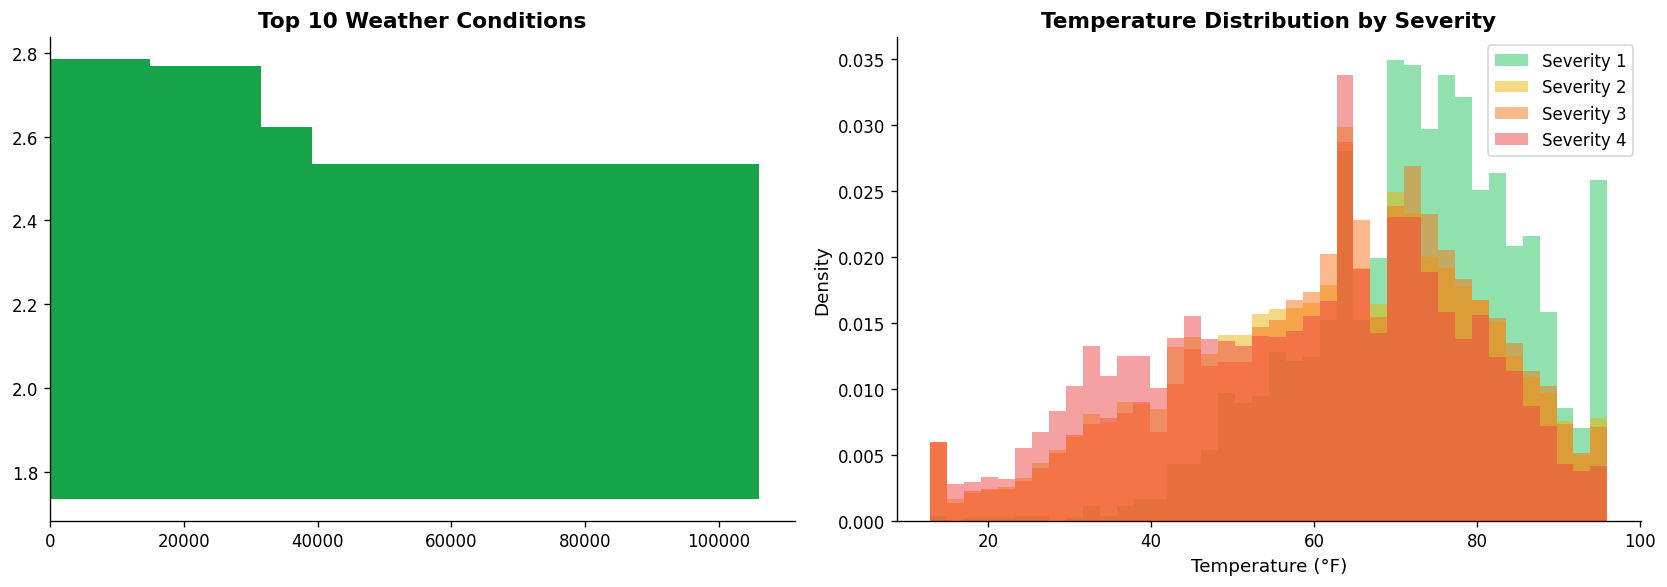

In [19]:

# ── 5.4 Weather Conditions ─────────────────────────────────────────────────────
if "Weather_Condition" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    top_weather = df["Weather_Condition"].value_counts().head(10)
    # Decode if encoded
    try:
        axes[0].barh(top_weather.index[::-1], top_weather.values[::-1], color="#16A34A")
    except:
        axes[0].barh(range(10), top_weather.values[::-1], color="#16A34A")
    axes[0].set_title("Top 10 Weather Conditions", fontweight="bold")

    # Temperature distribution by severity
    for sev in sorted(df["Severity"].unique()):
        subset = df[df["Severity"]==sev]["Temperature(F)"]
        axes[1].hist(subset, bins=40, alpha=0.5, label=f"Severity {sev}",
                     color=SEVERITY_COLORS.get(sev, "gray"), density=True)
    axes[1].set_title("Temperature Distribution by Severity", fontweight="bold")
    axes[1].set_xlabel("Temperature (°F)"); axes[1].set_ylabel("Density")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("05d_weather.png", bbox_inches="tight")
    plt.show()


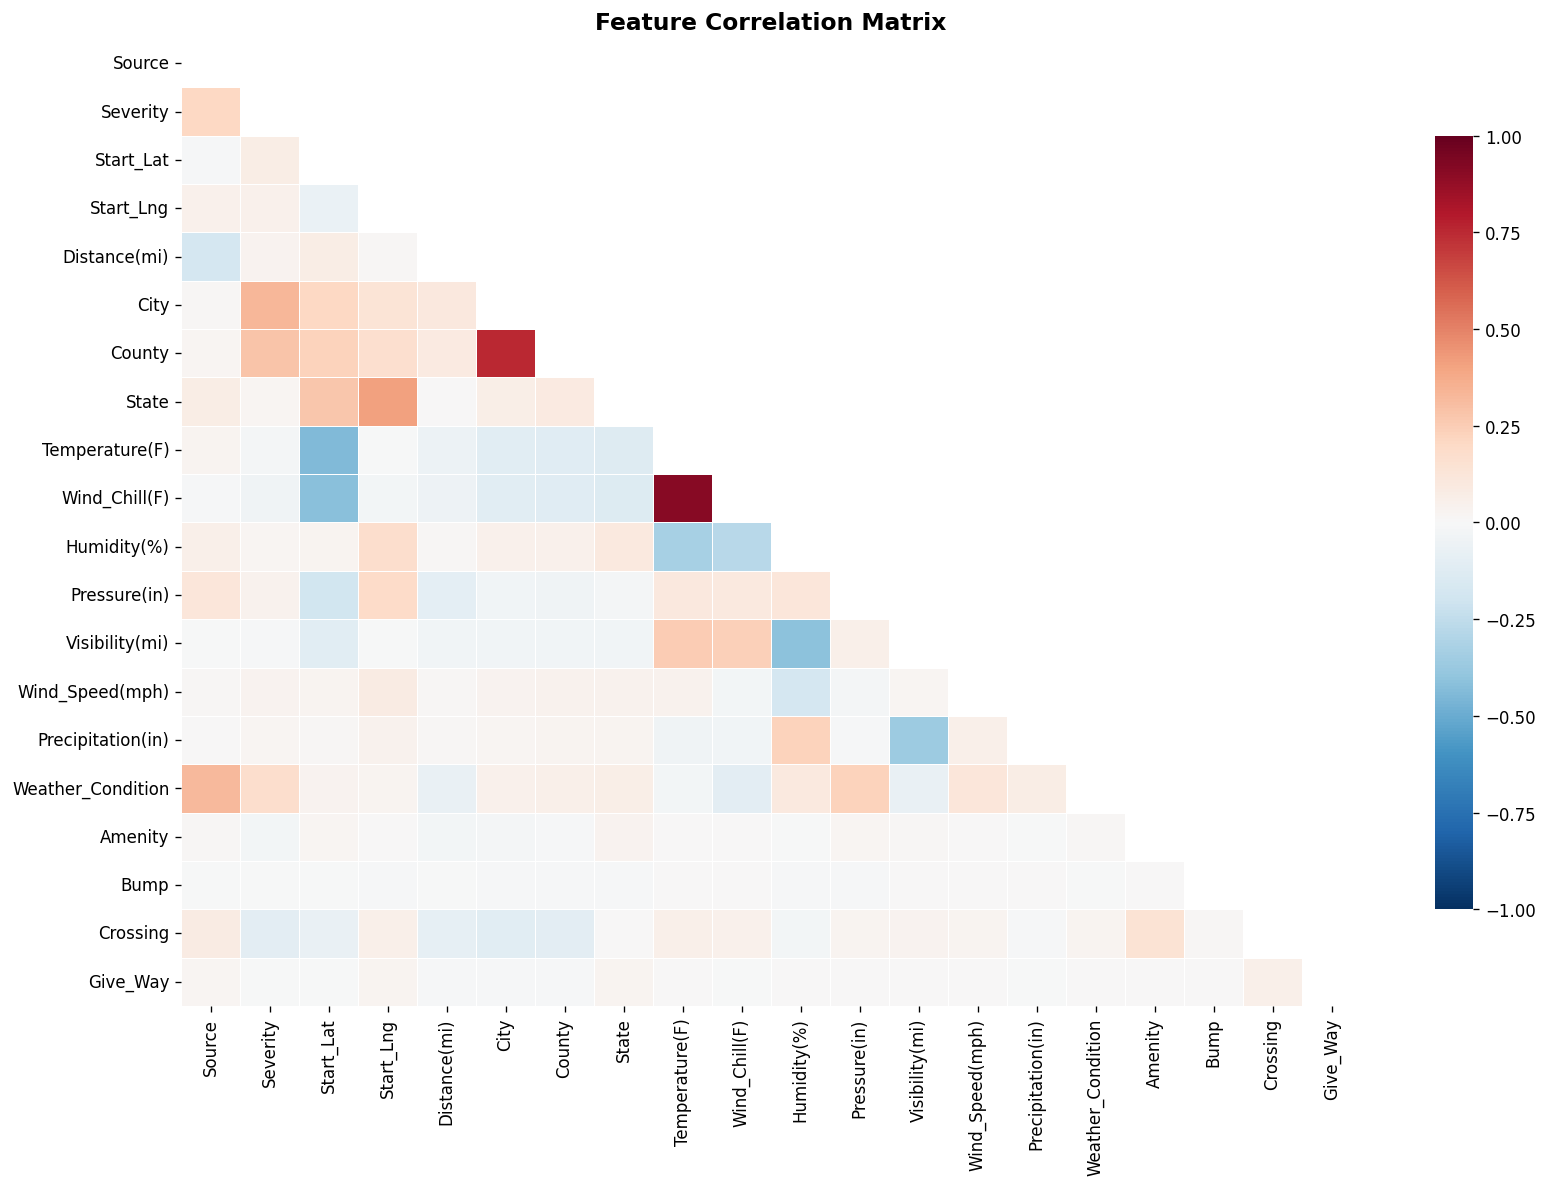

In [20]:

# ── 5.5 Correlation Matrix ─────────────────────────────────────────────────────
num_feats = df.select_dtypes(include=[np.number]).columns.tolist()
corr_feats = [c for c in num_feats if c in df.columns][:20]
corr_matrix = df[corr_feats].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, ax=ax, annot=False, cmap="RdBu_r",
            vmin=-1, vmax=1, linewidths=0.3, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig("05e_correlation.png", bbox_inches="tight")
plt.show()


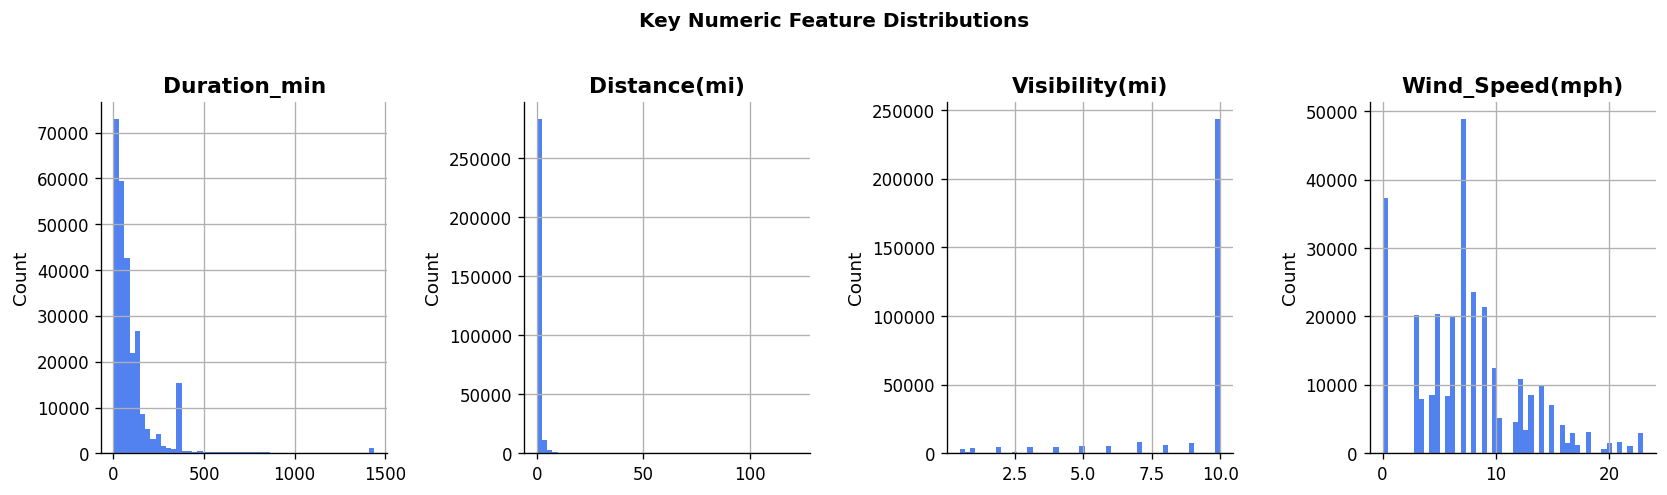

In [21]:

# ── 5.6 Key Feature Distributions ─────────────────────────────────────────────
feat_to_plot = [c for c in ["Duration_min","Distance(mi)","Visibility(mi)",
                              "Wind_Speed(mph)","Precipitation(in)"] if c in df.columns][:4]

fig, axes = plt.subplots(1, len(feat_to_plot), figsize=(14, 4))
if len(feat_to_plot) == 1:
    axes = [axes]

for ax, feat in zip(axes, feat_to_plot):
    df[feat].hist(bins=50, ax=ax, color="#2563EB", edgecolor="none", alpha=0.8)
    ax.set_title(feat, fontweight="bold")
    ax.set_ylabel("Count")

plt.suptitle("Key Numeric Feature Distributions", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("05f_distributions.png", bbox_inches="tight")
plt.show()


## 6 · Model Training

All models are trained on the SMOTE-balanced training set and evaluated on the held-out **test set**.

In [22]:

results = {}   # will hold metrics for all models

def evaluate(name, model, X_tr, y_tr, X_te, y_te, scaled=True):
    """Train, predict, compute metrics, store results."""
    t0 = time.time()
    model.fit(X_tr, y_tr)
    elapsed = time.time() - t0

    y_pred = model.predict(X_te)
    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred, average="weighted")

    # ROC-AUC (OvR)
    try:
        y_prob = model.predict_proba(X_te)
        y_bin  = label_binarize(y_te, classes=[0,1,2,3])
        roc    = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="weighted")
    except:
        roc = np.nan

    results[name] = {
        "model": model,
        "Accuracy": round(acc, 4),
        "F1 (weighted)": round(f1, 4),
        "ROC-AUC": round(roc, 4) if not np.isnan(roc) else "N/A",
        "Train_time_s": round(elapsed, 1),
        "y_pred": y_pred,
        "y_prob": y_prob if "y_prob" in dir() else None,
        "scaled": scaled
    }
    print(f"  ✅  {name:<25} | Acc={acc:.4f} | F1={f1:.4f} | AUC={roc:.4f} | {elapsed:.1f}s")
    return model

print("Training models …\n")


Training models …



In [23]:

# ── 6.1 Logistic Regression ────────────────────────────────────────────────────
print("── Logistic Regression ──")
lr = LogisticRegression(max_iter=1000, C=0.1, solver="lbfgs",
                        multi_class="multinomial", n_jobs=-1, random_state=42)
evaluate("Logistic Regression", lr, X_train_sm, y_train_sm, X_test_sc, y_test)


── Logistic Regression ──
  ✅  Logistic Regression       | Acc=0.5307 | F1=0.6053 | AUC=0.8136 | 6.9s


LogisticRegression(C=0.1, max_iter=1000, multi_class='multinomial', n_jobs=-1,
                   random_state=42)

In [24]:

# ── 6.2 Random Forest ─────────────────────────────────────────────────────────
print("── Random Forest ──")
rf = RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_leaf=5,
                             n_jobs=-1, random_state=42)
evaluate("Random Forest", rf, X_train_sm, y_train_sm, X_test_sc, y_test)


── Random Forest ──
  ✅  Random Forest             | Acc=0.8218 | F1=0.8375 | AUC=0.9150 | 366.6s


RandomForestClassifier(max_depth=20, min_samples_leaf=5, n_estimators=300,
                       n_jobs=-1, random_state=42)

In [25]:

# ── 6.3 XGBoost ───────────────────────────────────────────────────────────────
print("── XGBoost ──")
xgb = XGBClassifier(
    n_estimators=400, max_depth=7, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric="mlogloss",
    tree_method="hist", n_jobs=-1, random_state=42, verbosity=0
)
evaluate("XGBoost", xgb, X_train_sm, y_train_sm, X_test_sc, y_test)


── XGBoost ──
  ✅  XGBoost                   | Acc=0.8604 | F1=0.8589 | AUC=0.9173 | 86.1s


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=-1,
              num_parallel_tree=None, ...)

In [26]:

# ── 6.4 LightGBM ──────────────────────────────────────────────────────────────
print("── LightGBM ──")
lgbm = LGBMClassifier(
    n_estimators=400, max_depth=7, learning_rate=0.05,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8,
    n_jobs=-1, random_state=42, verbose=-1
)
evaluate("LightGBM", lgbm, X_train_sm, y_train_sm, X_test_sc, y_test)


── LightGBM ──
  ✅  LightGBM                  | Acc=0.8659 | F1=0.8612 | AUC=0.9203 | 68.0s


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, max_depth=7,
               n_estimators=400, n_jobs=-1, num_leaves=63, random_state=42,
               subsample=0.8, verbose=-1)

In [27]:

# ── 6.5 MLP (Neural Network) ──────────────────────────────────────────────────
print("── MLP Neural Network ──")
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64), activation="relu",
    solver="adam", alpha=1e-4, learning_rate_init=5e-4,
    max_iter=200, batch_size=1024, early_stopping=True,
    validation_fraction=0.1, random_state=42, verbose=False
)
evaluate("MLP Neural Network", mlp, X_train_sm, y_train_sm, X_test_sc, y_test)


── MLP Neural Network ──
  ✅  MLP Neural Network        | Acc=0.8010 | F1=0.8159 | AUC=0.8848 | 510.0s


MLPClassifier(batch_size=1024, early_stopping=True,
              hidden_layer_sizes=(256, 128, 64), learning_rate_init=0.0005,
              random_state=42)

## 7 · Evaluation & Model Comparison

In [28]:

# ── 7.1 Summary Table ─────────────────────────────────────────────────────────
metrics_df = pd.DataFrame([
    {
        "Model": name,
        "Accuracy": v["Accuracy"],
        "F1 (weighted)": v["F1 (weighted)"],
        "ROC-AUC": v["ROC-AUC"],
        "Train Time (s)": v["Train_time_s"]
    }
    for name, v in results.items()
]).set_index("Model").sort_values("F1 (weighted)", ascending=False)

display(metrics_df.style
    .background_gradient(cmap="YlGn", subset=["Accuracy","F1 (weighted)","ROC-AUC"])
    .bar(subset=["Train Time (s)"], color="#EAB308")
    .format({"Accuracy":"{:.4f}", "F1 (weighted)":"{:.4f}",
             "ROC-AUC": lambda x: f"{x:.4f}" if isinstance(x, float) else x,
             "Train Time (s)":"{:.1f}s"})
)


,Accuracy,F1 (weighted),ROC-AUC,Train Time (s)
Model,,,,
LightGBM,0.8659,0.8612,0.9203,68.0s
XGBoost,0.8604,0.8589,0.9173,86.1s
Random Forest,0.8218,0.8375,0.9150,366.6s
MLP Neural Network,0.8010,0.8159,0.8848,510.0s
Logistic Regression,0.5307,0.6053,0.8136,6.9s


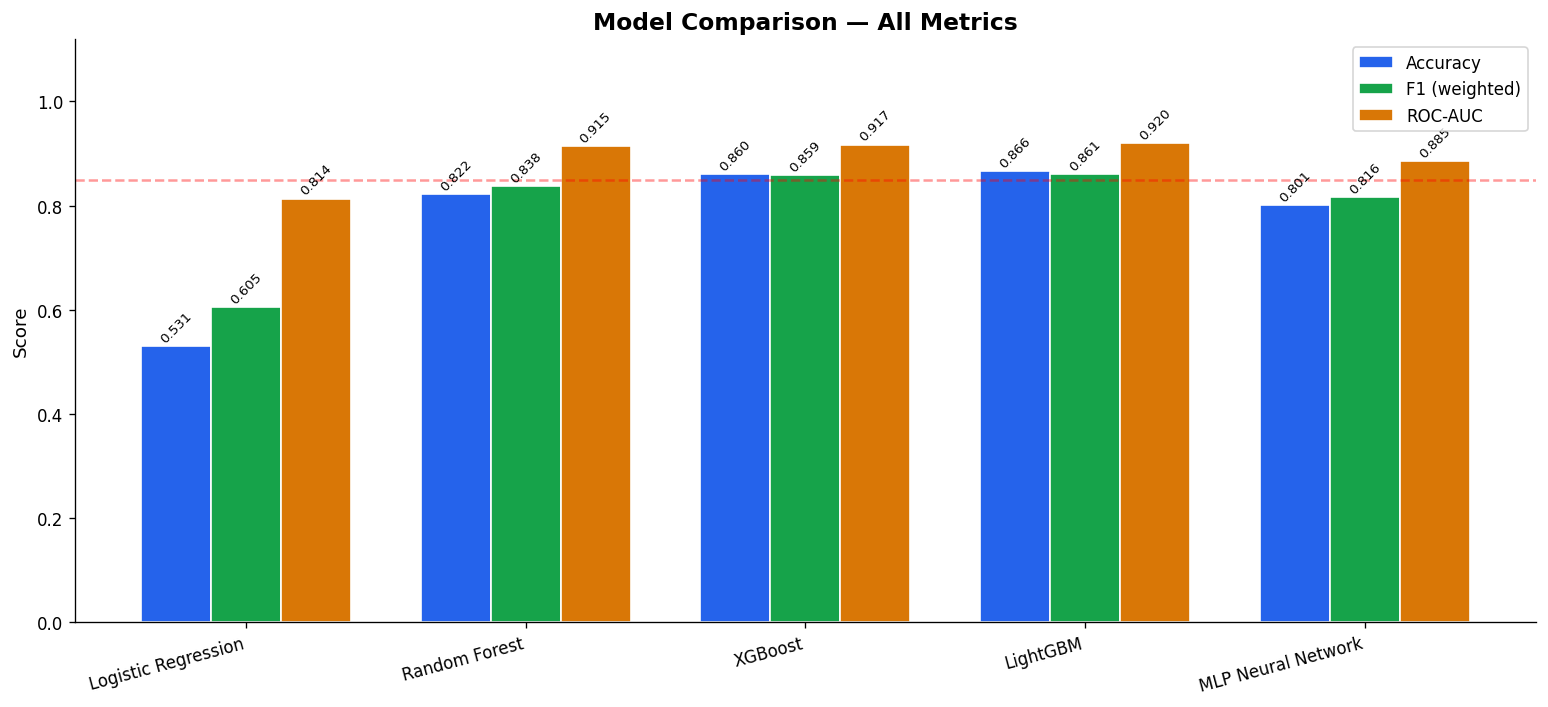

In [29]:

# ── 7.2 Grouped Bar Chart ─────────────────────────────────────────────────────
model_names = list(results.keys())
x = np.arange(len(model_names))
width = 0.25

acc_vals  = [results[m]["Accuracy"] for m in model_names]
f1_vals   = [results[m]["F1 (weighted)"] for m in model_names]
auc_vals  = [results[m]["ROC-AUC"] if isinstance(results[m]["ROC-AUC"], float) else 0
             for m in model_names]

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - width, acc_vals,  width, label="Accuracy",    color="#2563EB", edgecolor="white")
b2 = ax.bar(x,         f1_vals,   width, label="F1 (weighted)",color="#16A34A", edgecolor="white")
b3 = ax.bar(x + width, auc_vals,  width, label="ROC-AUC",     color="#D97706", edgecolor="white")

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x()+bar.get_width()/2, h+0.002, f"{h:.3f}",
                    ha="center", va="bottom", fontsize=8, rotation=45)

ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score"); ax.set_title("Model Comparison — All Metrics", fontweight="bold", fontsize=14)
ax.legend(loc="upper right")
ax.axhline(0.85, color="red", linestyle="--", alpha=0.4, label="0.85 target")

plt.tight_layout()
plt.savefig("07a_model_comparison.png", bbox_inches="tight")
plt.show()


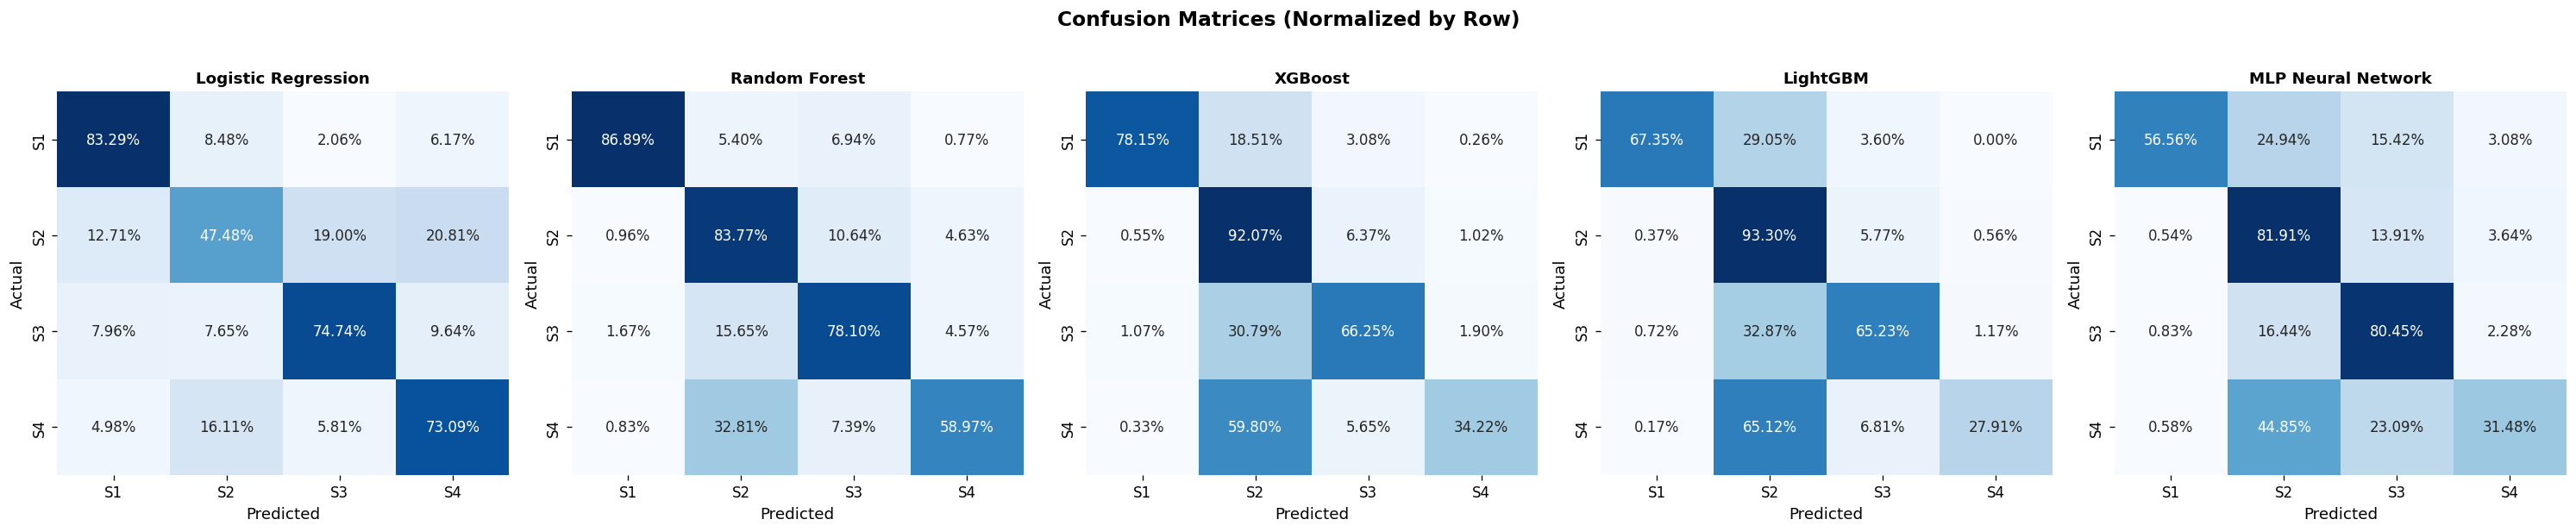

In [30]:

# ── 7.3 Confusion Matrices ────────────────────────────────────────────────────
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 5))

for ax, (name, v) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, v["y_pred"])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".2%", ax=ax,
                cmap="Blues", cbar=False,
                xticklabels=["S1","S2","S3","S4"],
                yticklabels=["S1","S2","S3","S4"])
    ax.set_title(name, fontweight="bold", fontsize=11)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices (Normalized by Row)", fontweight="bold", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("07b_confusion_matrices.png", bbox_inches="tight")
plt.show()


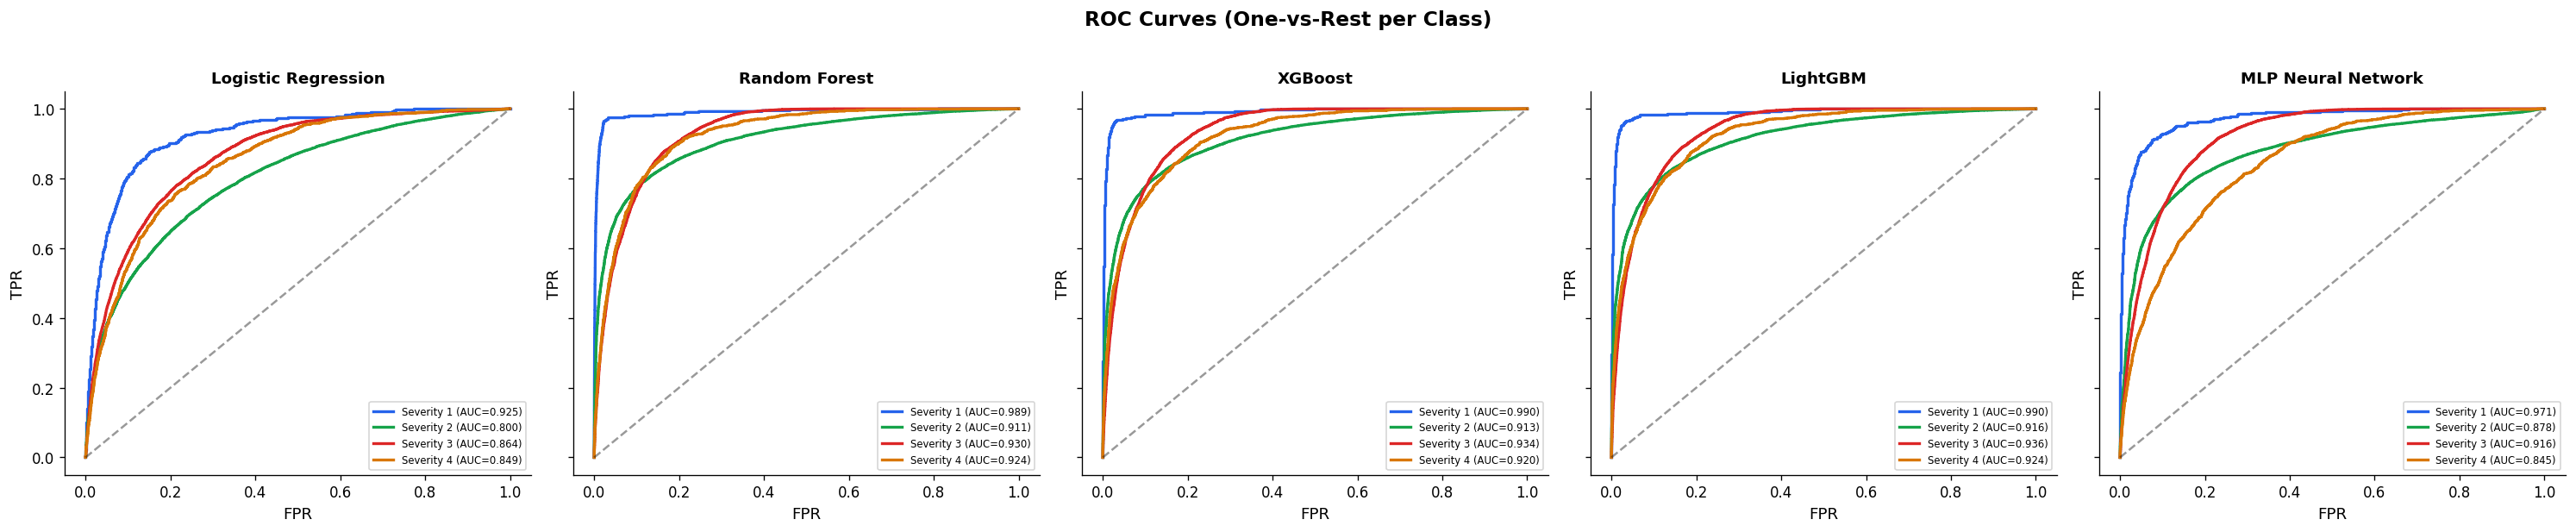

In [31]:

# ── 7.4 ROC Curves (OvR) ─────────────────────────────────────────────────────
class_labels = ["Severity 1","Severity 2","Severity 3","Severity 4"]
colors_roc = ["#2563EB","#16A34A","#DC2626","#D97706"]

fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 5), sharey=True)

for ax, (name, v) in zip(axes, results.items()):
    if v["y_prob"] is None:
        ax.text(0.5, 0.5, "N/A", ha="center", va="center")
        ax.set_title(name)
        continue
    y_bin = label_binarize(y_test, classes=[0,1,2,3])
    for i, (label, clr) in enumerate(zip(class_labels, colors_roc)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], v["y_prob"][:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=clr, linewidth=2, label=f"{label} (AUC={roc_auc:.3f})")
    ax.plot([0,1],[0,1],"k--", alpha=0.4)
    ax.set_title(name, fontweight="bold", fontsize=11)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.legend(fontsize=7, loc="lower right")

plt.suptitle("ROC Curves (One-vs-Rest per Class)", fontweight="bold", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("07c_roc_curves.png", bbox_inches="tight")
plt.show()


In [32]:

# ── 7.5 Per-class Classification Reports ──────────────────────────────────────
for name, v in results.items():
    print(f"\n{'='*60}")
    print(f"  {name}")
    print('='*60)
    print(classification_report(y_test, v["y_pred"],
                                 target_names=["Severity-1","Severity-2","Severity-3","Severity-4"]))



  Logistic Regression
              precision    recall  f1-score   support

  Severity-1       0.06      0.83      0.11       389
  Severity-2       0.95      0.47      0.63     35817
  Severity-3       0.45      0.75      0.56      7590
  Severity-4       0.10      0.73      0.17      1204

    accuracy                           0.53     45000
   macro avg       0.39      0.70      0.37     45000
weighted avg       0.84      0.53      0.61     45000


  Random Forest
              precision    recall  f1-score   support

  Severity-1       0.41      0.87      0.56       389
  Severity-2       0.95      0.84      0.89     35817
  Severity-3       0.60      0.78      0.68      7590
  Severity-4       0.26      0.59      0.36      1204

    accuracy                           0.82     45000
   macro avg       0.56      0.77      0.62     45000
weighted avg       0.87      0.82      0.84     45000


  XGBoost
              precision    recall  f1-score   support

  Severity-1       0.52 

## 8 · Feature Importance

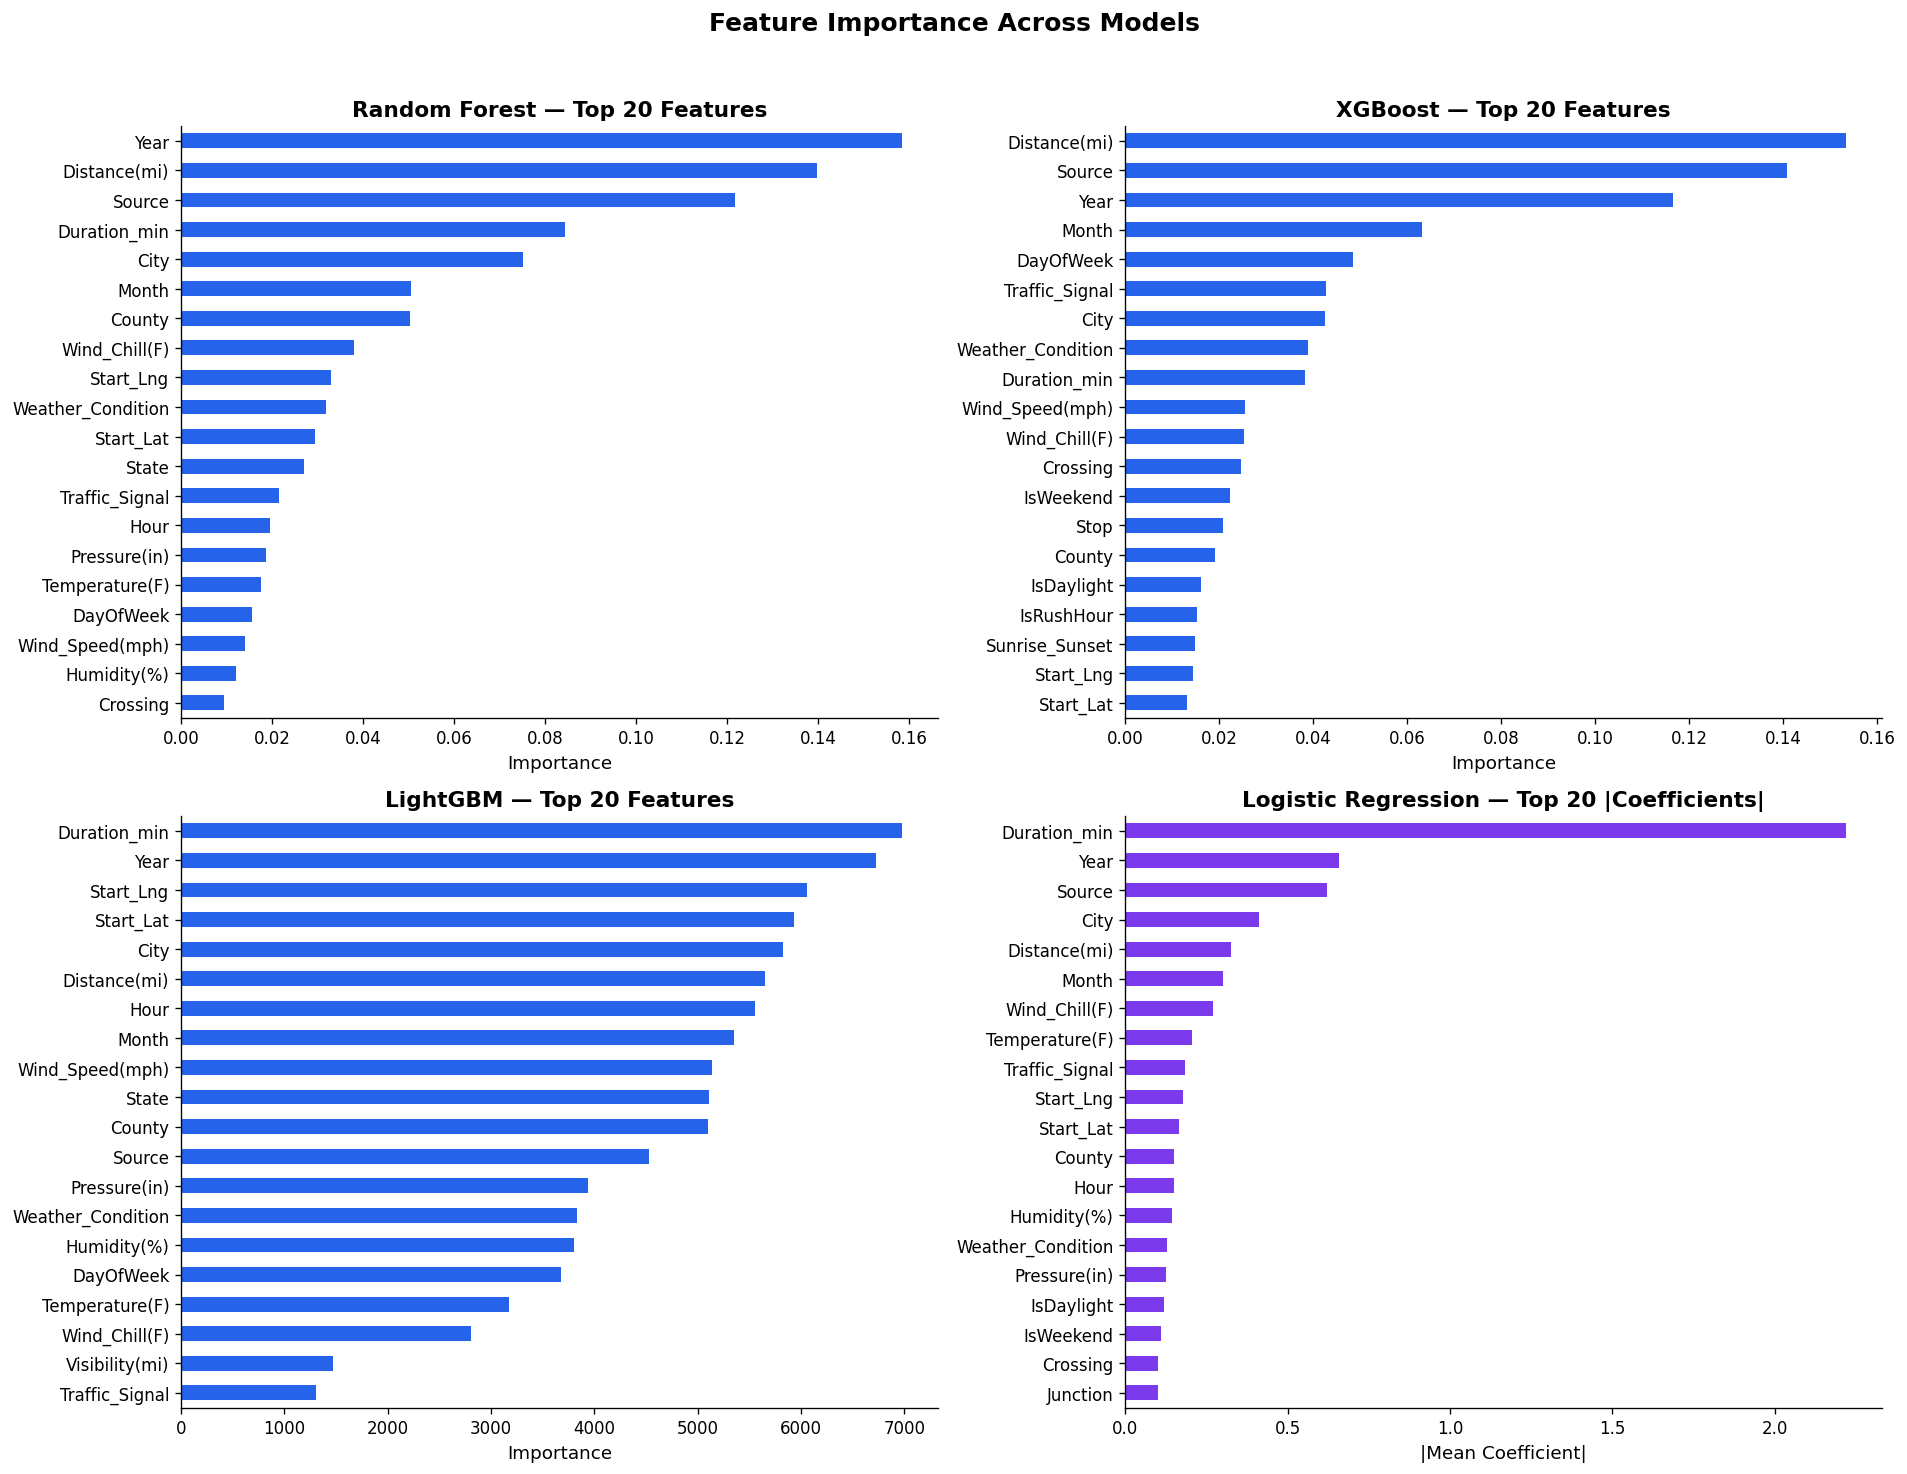

In [33]:

feature_names = list(X.columns)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

tree_models = [(n, v) for n, v in results.items()
               if hasattr(v["model"], "feature_importances_")]

for ax, (name, v) in zip(axes, tree_models):
    imp = v["model"].feature_importances_
    imp_df = pd.Series(imp, index=feature_names).sort_values(ascending=False).head(20)
    imp_df[::-1].plot(kind="barh", ax=ax, color="#2563EB", edgecolor="none")
    ax.set_title(f"{name} — Top 20 Features", fontweight="bold")
    ax.set_xlabel("Importance")

# LR coefficients
if "Logistic Regression" in results:
    ax = axes[len(tree_models)]
    lr_model = results["Logistic Regression"]["model"]
    coef_mean = np.abs(lr_model.coef_).mean(axis=0)
    coef_df = pd.Series(coef_mean, index=feature_names).sort_values(ascending=False).head(20)
    coef_df[::-1].plot(kind="barh", ax=ax, color="#7C3AED", edgecolor="none")
    ax.set_title("Logistic Regression — Top 20 |Coefficients|", fontweight="bold")
    ax.set_xlabel("|Mean Coefficient|")

plt.suptitle("Feature Importance Across Models", fontweight="bold", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("08_feature_importance.png", bbox_inches="tight")
plt.show()


## 9 · Summary, Winner & Recommendations

In [34]:

print("\n" + "="*70)
print("   FINAL MODEL COMPARISON SUMMARY")
print("="*70)
display(metrics_df)

best_model = metrics_df["F1 (weighted)"].idxmax()
best_f1    = metrics_df.loc[best_model, "F1 (weighted)"]
best_acc   = metrics_df.loc[best_model, "Accuracy"]
best_auc   = metrics_df.loc[best_model, "ROC-AUC"]

print(f"\n🏆  Best Model: {best_model}")
print(f"    Accuracy   : {best_acc:.4f}")
print(f"    F1 (weighted): {best_f1:.4f}")
print(f"    ROC-AUC    : {best_auc}")
print("="*70)



   FINAL MODEL COMPARISON SUMMARY


,Accuracy,F1 (weighted),ROC-AUC,Train Time (s)
Model,,,,
LightGBM,0.8659,0.8612,0.9203,68.0
XGBoost,0.8604,0.8589,0.9173,86.1
Random Forest,0.8218,0.8375,0.9150,366.6
MLP Neural Network,0.8010,0.8159,0.8848,510.0
Logistic Regression,0.5307,0.6053,0.8136,6.9



🏆  Best Model: LightGBM
    Accuracy   : 0.8659
    F1 (weighted): 0.8612
    ROC-AUC    : 0.9203


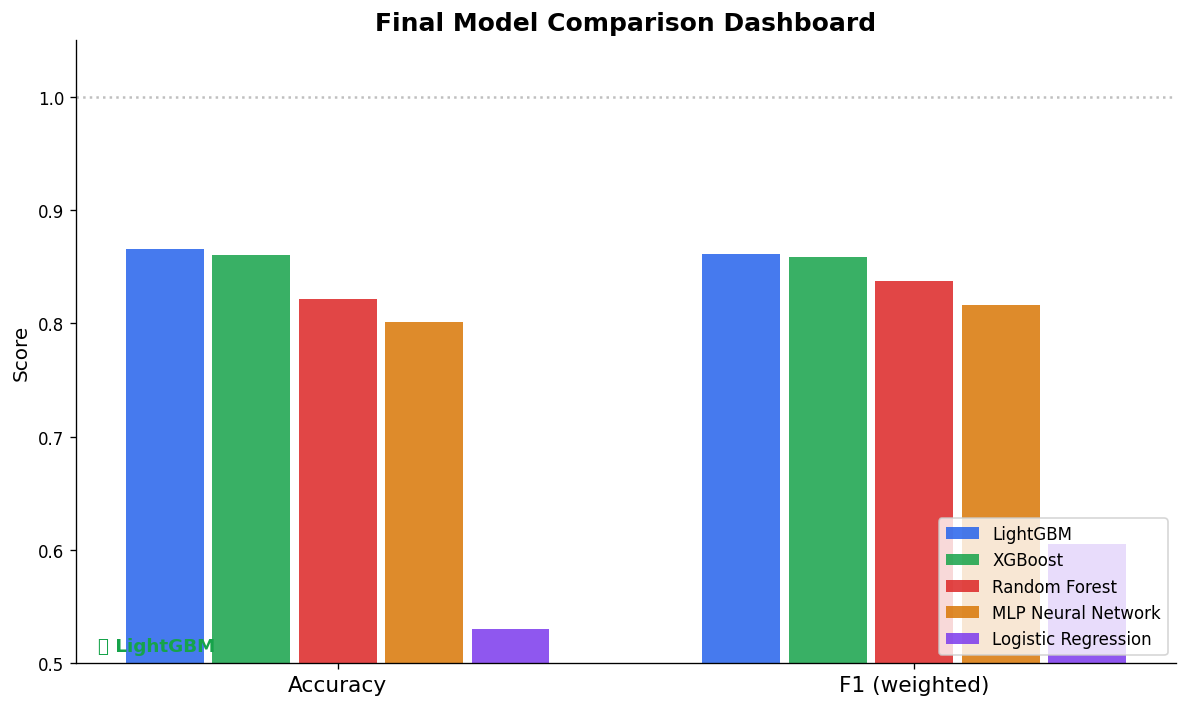

In [35]:

# ── Radar / Spider chart for visual model comparison ─────────────────────────
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

metrics_to_plot = ["Accuracy", "F1 (weighted)"]
auc_col = "ROC-AUC"
model_list = metrics_df.index.tolist()

fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.15
x_base = np.arange(2)

for i, (model_name, clr) in enumerate(zip(model_list, PALETTE)):
    vals = [metrics_df.loc[model_name, "Accuracy"],
            metrics_df.loc[model_name, "F1 (weighted)"]]
    ax.bar(x_base + i*bar_width, vals, bar_width*0.9, label=model_name, color=clr, alpha=0.85)

ax.set_xticks(x_base + bar_width*(len(model_list)-1)/2)
ax.set_xticklabels(["Accuracy", "F1 (weighted)"], fontsize=13)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Final Model Comparison Dashboard", fontweight="bold", fontsize=15)
ax.legend(loc="lower right", fontsize=10)
ax.axhline(1.0, color="gray", linestyle=":", alpha=0.5)

# Annotate winner
ax.annotate(f"🏆 {best_model}", xy=(0, 0), xycoords="axes fraction",
            xytext=(0.02, 0.02), textcoords="axes fraction",
            fontsize=11, color="#16A34A", fontweight="bold")

plt.tight_layout()
plt.savefig("09_final_comparison.png", bbox_inches="tight")
plt.show()
